In [26]:
import nibabel as nib
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.decomposition import PCA



In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from itertools import combinations

In [31]:
df = pd.read_csv(r"D:\New folder\DTI_ROI_features.csv")

In [32]:
X = df.drop(
    columns=["Subject", "Original_ID", "Label"]
)

y = df["Label"]

print(df)

   Subject  Original_ID Label   ROI1_FA   ROI1_MD   ROI1_AD   ROI1_RD  \
0       S1   002_S_1155   MCI  0.458611  0.000804  0.001213  0.000600   
1       S2   002_S_4799   MCI  0.438620  0.000759  0.001136  0.000571   
2       S3  003_S_10426   MCI  0.381798  0.001088  0.001467  0.000899   
3       S4   003_S_6258   MCI  0.446981  0.000771  0.001157  0.000578   
4       S5   003_S_6268   MCI  0.507050  0.000693  0.001123  0.000478   
5       S6  005_S_10205   MCI  0.350469  0.000862  0.001188  0.000698   
6       S7  005_S_10658   MCI  0.378257  0.001284  0.001715  0.001069   
7       S8   024_S_2239   MCI  0.418516  0.000909  0.001306  0.000711   
8       S9  033_S_10025   MCI  0.426983  0.000818  0.001187  0.000634   
9      S10  035_S_10340   MCI  0.479472  0.000836  0.001261  0.000624   
10     S11   035_S_6480   MCI  0.469813  0.000869  0.001296  0.000656   
11     S12   002_S_1280    CN  0.461670  0.001000  0.001449  0.000775   
12     S13   002_S_4213    CN  0.372567  0.001315  

In [33]:
print(df["Label"].value_counts())

Label
MCI    11
CN     11
Name: count, dtype: int64


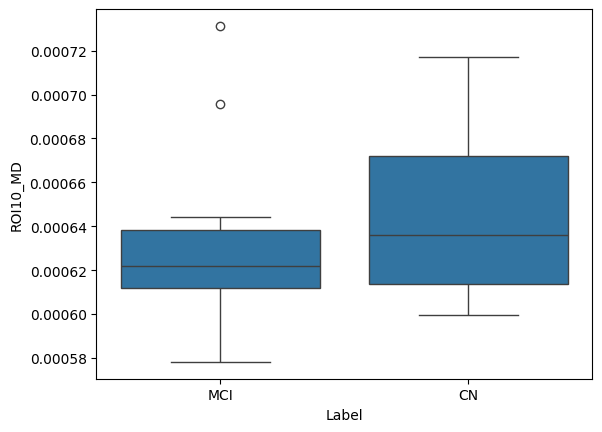

In [38]:
sns.boxplot(
    x="Label",
    y="ROI10_MD",
    data=df
)

plt.show()

# Step 3: Rank ROIs by discriminative power
Rather than manually inspecting 50 ROIs, compute an ANOVA F-score:

In [39]:
X = df.filter(regex="_FA$")
y = df["Label"]

F, p = f_classif(X, y)

ranking = (
    pd.DataFrame({
        "Feature": X.columns,
        "F_score": F,
        "p_value": p
    })
    .sort_values("F_score", ascending=False)
)

print(ranking.head(20))

     Feature    F_score   p_value
18  ROI19_FA  11.188748  0.003225
33  ROI34_FA   5.905916  0.024628
34  ROI35_FA   5.665063  0.027368
35  ROI36_FA   5.283052  0.032449
3    ROI4_FA   4.861241  0.039340
19  ROI20_FA   4.088392  0.056761
49  ROI50_FA   3.422604  0.079141
42  ROI43_FA   3.063681  0.095387
48  ROI49_FA   2.919579  0.102985
4    ROI5_FA   2.900110  0.104065
30  ROI31_FA   2.726603  0.114305
22  ROI23_FA   2.462965  0.132245
5    ROI6_FA   2.357893  0.140320
38  ROI39_FA   2.226602  0.151259
44  ROI45_FA   2.192715  0.154247
2    ROI3_FA   1.955193  0.177343
16  ROI17_FA   1.816125  0.192844
24  ROI25_FA   1.688842  0.208534
13  ROI14_FA   1.184474  0.289389
43  ROI44_FA   1.144971  0.297349


# Step 5: Check global separation with PCA

In [40]:


X = df.drop(
    columns=["Subject","Original_ID","Label"]
)

X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

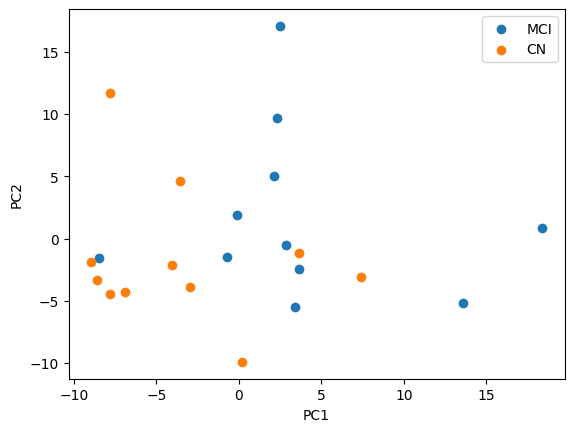

In [41]:
for label in ["MCI", "CN"]:

    idx = df["Label"] == label

    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        label=label
    )

plt.legend()
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
# For 3 classes
X1 = dfMC.drop(
    columns=["Subject","Original_ID","Label"]
)

X1 = StandardScaler().fit_transform(X1)

pca1 = PCA(n_components=2)

X_pca1 = pca1.fit_transform(X1)

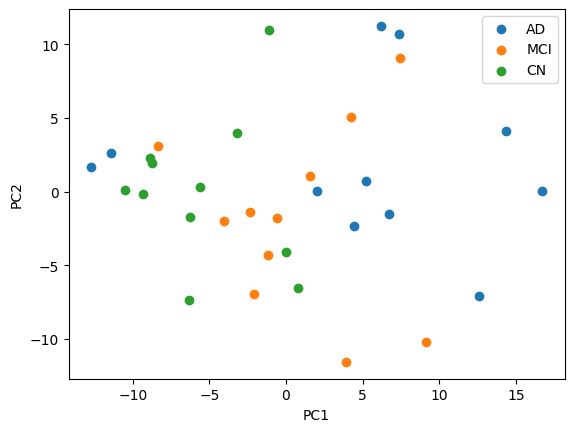

In [16]:
for label in ["AD", "MCI", "CN"]:

    idx = dfMC["Label"] == label

    plt.scatter(
        X_pca1[idx,0],
        X_pca1[idx,1],
        label=label
    )

plt.legend()
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Step 6: Remove useless features 
Some ROIs may be nearly constant.

In [9]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(
    threshold=1e-6
)

X = selector.fit_transform(X)

In [10]:
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    SelectKBest,
    f_classif
)

from sklearn.svm import SVC

In [ ]:
# Binary classification


def run_experiment(
    df,
    model_name="rbf_svm",
    k_features=5,
    n_permutations=1000,
    positive_label="CN"
):

    # =====================================================
    # DATA
    # =====================================================

    y = df["Label"]
    metrics = ["FA", "MD", "AD", "RD"]

    loo = LeaveOneOut()

    # =====================================================
    # MODEL SELECTION
    # =====================================================

    if model_name == "logistic":

        classifier = LogisticRegression(
            max_iter=1000,
            penalty="l2",
            C=1.0,
            random_state=42
        )

    elif model_name == "linear_svm":

        classifier = SVC(
            kernel="linear",
            C=1.0
        )

    elif model_name == "rbf_svm":

        classifier = SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale"
        )

    elif model_name == "random_forest":

        classifier = RandomForestClassifier(
            n_estimators = 200,
            random_state = 42,
            n_jobs = 1
        )

    else:
        raise ValueError("Unknown model")

    # =====================================================
    # PIPELINE
    # =====================================================

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("feature_selection",
         SelectKBest(f_classif, k=k_features)),
        ("classifier", classifier)
    ])

    # =====================================================
    # RESULTS
    # =====================================================

    results = []

    rng = np.random.RandomState(42)

    # =====================================================
    # ABALATION LOOP
    # =====================================================

    for r in range(1, 5):

        for combo in combinations(metrics, r):

            print(f"\n[{model_name}] Running {combo}")

            cols = []

            for m in combo:
                cols.extend(
                    df.filter(regex=f"_{m}$").columns
                )

            X = df[cols]

            # -----------------------------------
            # REAL MODEL
            # -----------------------------------

            y_pred = cross_val_predict(
                clf,
                X,
                y,
                cv=loo,
                n_jobs = -1
            )

            acc = accuracy_score(y, y_pred)
            bal_acc = balanced_accuracy_score(y, y_pred)

            f1 = f1_score(
                y,
                y_pred,
                pos_label=positive_label
            )

            precision = precision_score(
                y,
                y_pred,
                pos_label=positive_label
            )

            recall = recall_score(
                y,
                y_pred,
                pos_label=positive_label
            )

            cm = confusion_matrix(y, y_pred)

            # -----------------------------------
            # PERMUTATION
            # -----------------------------------

            perm_accs = []

            for _ in range(n_permutations):

                y_perm = rng.permutation(y)

                y_pred_perm = cross_val_predict(
                    clf,
                    X,
                    y_perm,
                    cv=loo,
                    n_jobs = -1
                )

                perm_accs.append(
                    accuracy_score(
                        y_perm,
                        y_pred_perm
                    )
                )

            p_value = np.mean(
                np.array(perm_accs) >= acc
            )

            print("Accuracy:", round(acc, 3))
            print("p-value:", round(p_value, 4))

            results.append({
                "Model": model_name,
                "Features": "+".join(combo),
                "Num_Features": X.shape[1],

                "Accuracy": acc,
                "Balanced_Accuracy": bal_acc,

                "F1": f1,
                "Precision": precision,
                "Recall": recall,

                "p_value": p_value
            })

    # =====================================================
    # FINAL TABLE
    # =====================================================

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by="Balanced_Accuracy",
        ascending=False
    )

    filename = f"{model_name}_ablation_results.csv"

    results_df.to_csv(
        filename,
        index=False
    )

    print(f"\nSaved: {filename}")

    return results_df

In [ ]:
# Multiclass classification


def run_experimentMC(
    df,
    model_name="rbf_svm",
    k_features=4,
    n_permutations=1000
):

    # =====================================================
    # DATA
    # =====================================================

    y = df["Label"]

    metrics = ["FA", "MD", "AD", "RD"]

    loo = LeaveOneOut()

    # =====================================================
    # MODEL SELECTION
    # =====================================================

    if model_name == "logistic":

        classifier = LogisticRegression(
            max_iter=1000,
            penalty="l2",
            C=1.0,
            random_state=42
        )

    elif model_name == "linear_svm":

        classifier = SVC(
            kernel="linear",
            C=1.0
        )

    elif model_name == "rbf_svm":

        classifier = SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale"
        )

    elif model_name == "random_forest":

        classifier = RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=1
        )

    else:
        raise ValueError("Unknown model")

    # =====================================================
    # PIPELINE
    # =====================================================

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("feature_selection",
         SelectKBest(
             f_classif,
             k=k_features
         )),
        ("classifier", classifier)
    ])

    # =====================================================
    # RESULTS
    # =====================================================

    results = []

    rng = np.random.RandomState(42)

    # =====================================================
    # ABALATION LOOP
    # =====================================================

    for r in range(1, 5):

        for combo in combinations(metrics, r):

            print(f"\n[{model_name}] Running {combo}")

            # -----------------------------------
            # BUILD FEATURE MATRIX
            # -----------------------------------

            cols = []

            for m in combo:

                cols.extend(
                    df.filter(
                        regex=f"_{m}$"
                    ).columns
                )

            X = df[cols]

            # -----------------------------------
            # REAL MODEL (LOOCV)
            # -----------------------------------

            y_pred = cross_val_predict(
                clf,
                X,
                y,
                cv=loo,
                n_jobs=-1
            )

            acc = accuracy_score(
                y,
                y_pred
            )

            bal_acc = balanced_accuracy_score(
                y,
                y_pred
            )

            f1_macro = f1_score(
                y,
                y_pred,
                average="macro"
            )

            f1_weighted = f1_score(
                y,
                y_pred,
                average="weighted"
            )

            precision_macro = precision_score(
                y,
                y_pred,
                average="macro",
                zero_division=0
            )

            recall_macro = recall_score(
                y,
                y_pred,
                average="macro",
                zero_division=0
            )

            cm = confusion_matrix(
                y,
                y_pred,
                labels=sorted(y.unique())
            )

            # -----------------------------------
            # PERMUTATION TEST
            # -----------------------------------

            perm_accs = []

            for _ in range(n_permutations):

                y_perm = rng.permutation(y)

                y_pred_perm = cross_val_predict(
                    clf,
                    X,
                    y_perm,
                    cv=loo,
                    n_jobs=-1
                )

                perm_acc = accuracy_score(
                    y_perm,
                    y_pred_perm
                )

                perm_accs.append(
                    perm_acc
                )

            perm_accs = np.array(
                perm_accs
            )

            p_value = np.mean(
                perm_accs >= acc
            )

            # -----------------------------------
            # PRINT RESULTS
            # -----------------------------------

            print("\nLabels:",
                  sorted(y.unique()))

            print("Confusion Matrix:")
            print(cm)

            print(
                "Accuracy:",
                round(acc, 3)
            )

            print(
                "Balanced Accuracy:",
                round(bal_acc, 3)
            )

            print(
                "F1 Macro:",
                round(f1_macro, 3)
            )

            print(
                "p-value:",
                round(p_value, 4)
            )

            # -----------------------------------
            # STORE RESULTS
            # -----------------------------------

            results.append({

                "Model": model_name,

                "Features":
                    "+".join(combo),

                "Num_Features":
                    X.shape[1],

                "Accuracy":
                    acc,

                "Balanced_Accuracy":
                    bal_acc,

                "F1_Macro":
                    f1_macro,

                "F1_Weighted":
                    f1_weighted,

                "Precision_Macro":
                    precision_macro,

                "Recall_Macro":
                    recall_macro,

                "p_value":
                    p_value
            })

    # =====================================================
    # FINAL RESULTS TABLE
    # =====================================================

    results_df = pd.DataFrame(
        results
    )

    results_df = results_df.sort_values(
        by="Balanced_Accuracy",
        ascending=False
    )

    filename = (
        f"{model_name}_ablation_resultsMC.csv"
    )

    results_df.to_csv(
        filename,
        index=False
    )

    print(
        f"\nSaved: {filename}"
    )

    return results_df

# Call your model 

In [13]:
X = df.drop(
    columns=["Subject", "Original_ID"]
)

In [14]:
results_svm = run_experiment(
    X,
    model_name="linear_svm",
    n_permutations=500
)


[linear_svm] Running ('FA',)
Accuracy: 0.5
p-value: 0.498

[linear_svm] Running ('MD',)
Accuracy: 0.773
p-value: 0.028

[linear_svm] Running ('AD',)
Accuracy: 0.727
p-value: 0.06

[linear_svm] Running ('RD',)
Accuracy: 0.773
p-value: 0.046

[linear_svm] Running ('FA', 'MD')
Accuracy: 0.682
p-value: 0.122

[linear_svm] Running ('FA', 'AD')
Accuracy: 0.682
p-value: 0.144

[linear_svm] Running ('FA', 'RD')
Accuracy: 0.682
p-value: 0.17

[linear_svm] Running ('MD', 'AD')
Accuracy: 0.727
p-value: 0.086

[linear_svm] Running ('MD', 'RD')
Accuracy: 0.773
p-value: 0.042

[linear_svm] Running ('AD', 'RD')
Accuracy: 0.773
p-value: 0.044

[linear_svm] Running ('FA', 'MD', 'AD')
Accuracy: 0.773
p-value: 0.048

[linear_svm] Running ('FA', 'MD', 'RD')
Accuracy: 0.773
p-value: 0.048

[linear_svm] Running ('FA', 'AD', 'RD')
Accuracy: 0.773
p-value: 0.044

[linear_svm] Running ('MD', 'AD', 'RD')
Accuracy: 0.773
p-value: 0.046

[linear_svm] Running ('FA', 'MD', 'AD', 'RD')
Accuracy: 0.773
p-value: 0.05

In [15]:
results_rbf = run_experiment(
    X,
    model_name="rbf_svm",
    n_permutations=500
)



[rbf_svm] Running ('FA',)
Accuracy: 0.636
p-value: 0.178

[rbf_svm] Running ('MD',)
Accuracy: 0.773
p-value: 0.028

[rbf_svm] Running ('AD',)
Accuracy: 0.773
p-value: 0.022

[rbf_svm] Running ('RD',)
Accuracy: 0.818
p-value: 0.016

[rbf_svm] Running ('FA', 'MD')
Accuracy: 0.773
p-value: 0.02

[rbf_svm] Running ('FA', 'AD')
Accuracy: 0.727
p-value: 0.072

[rbf_svm] Running ('FA', 'RD')
Accuracy: 0.773
p-value: 0.04

[rbf_svm] Running ('MD', 'AD')
Accuracy: 0.773
p-value: 0.03

[rbf_svm] Running ('MD', 'RD')
Accuracy: 0.773
p-value: 0.036

[rbf_svm] Running ('AD', 'RD')
Accuracy: 0.773
p-value: 0.04

[rbf_svm] Running ('FA', 'MD', 'AD')
Accuracy: 0.773
p-value: 0.044

[rbf_svm] Running ('FA', 'MD', 'RD')
Accuracy: 0.773
p-value: 0.038

[rbf_svm] Running ('FA', 'AD', 'RD')
Accuracy: 0.773
p-value: 0.044

[rbf_svm] Running ('MD', 'AD', 'RD')
Accuracy: 0.773
p-value: 0.026

[rbf_svm] Running ('FA', 'MD', 'AD', 'RD')
Accuracy: 0.773
p-value: 0.036

Saved: rbf_svm_ablation_results.csv


In [16]:
results_lr = run_experiment(
    X,
    model_name="logistic",
    n_permutations=500
)


[logistic] Running ('FA',)
Accuracy: 0.545
p-value: 0.376

[logistic] Running ('MD',)
Accuracy: 0.773
p-value: 0.026

[logistic] Running ('AD',)
Accuracy: 0.773
p-value: 0.02

[logistic] Running ('RD',)
Accuracy: 0.727
p-value: 0.062

[logistic] Running ('FA', 'MD')
Accuracy: 0.727
p-value: 0.07

[logistic] Running ('FA', 'AD')
Accuracy: 0.773
p-value: 0.036

[logistic] Running ('FA', 'RD')
Accuracy: 0.727
p-value: 0.09

[logistic] Running ('MD', 'AD')
Accuracy: 0.773
p-value: 0.024

[logistic] Running ('MD', 'RD')
Accuracy: 0.773
p-value: 0.032

[logistic] Running ('AD', 'RD')
Accuracy: 0.773
p-value: 0.038

[logistic] Running ('FA', 'MD', 'AD')
Accuracy: 0.773
p-value: 0.032

[logistic] Running ('FA', 'MD', 'RD')
Accuracy: 0.773
p-value: 0.042

[logistic] Running ('FA', 'AD', 'RD')
Accuracy: 0.773
p-value: 0.028

[logistic] Running ('MD', 'AD', 'RD')
Accuracy: 0.773
p-value: 0.038

[logistic] Running ('FA', 'MD', 'AD', 'RD')
Accuracy: 0.773
p-value: 0.046

Saved: logistic_ablation_r

In [17]:
results_rf = run_experiment(
    X,
    model_name="random_forest",
    n_permutations=100
)


[random_forest] Running ('FA',)
Accuracy: 0.545
p-value: 0.34

[random_forest] Running ('MD',)
Accuracy: 0.818
p-value: 0.0

[random_forest] Running ('AD',)
Accuracy: 0.773
p-value: 0.01

[random_forest] Running ('RD',)
Accuracy: 0.773
p-value: 0.01

[random_forest] Running ('FA', 'MD')
Accuracy: 0.773
p-value: 0.01

[random_forest] Running ('FA', 'AD')
Accuracy: 0.818
p-value: 0.02

[random_forest] Running ('FA', 'RD')
Accuracy: 0.727
p-value: 0.06

[random_forest] Running ('MD', 'AD')
Accuracy: 0.773
p-value: 0.03

[random_forest] Running ('MD', 'RD')
Accuracy: 0.682
p-value: 0.12

[random_forest] Running ('AD', 'RD')
Accuracy: 0.773
p-value: 0.03

[random_forest] Running ('FA', 'MD', 'AD')
Accuracy: 0.773
p-value: 0.03

[random_forest] Running ('FA', 'MD', 'RD')
Accuracy: 0.727
p-value: 0.07

[random_forest] Running ('FA', 'AD', 'RD')
Accuracy: 0.773
p-value: 0.05

[random_forest] Running ('MD', 'AD', 'RD')
Accuracy: 0.818
p-value: 0.01

[random_forest] Running ('FA', 'MD', 'AD', '

In [19]:
X1 = dfMC.drop(
    columns=["Subject", "Original_ID"]
)

In [20]:
results_svm = run_experimentMC(
    X1,
    model_name="linear_svm",
    n_permutations=500
)


[linear_svm] Running ('FA',)

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[4 4 3]
 [3 4 4]
 [2 4 5]]
Accuracy: 0.394
Balanced Accuracy: 0.394
F1 Macro: 0.394
p-value: 0.286

[linear_svm] Running ('MD',)

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[3 2 6]
 [1 9 1]
 [4 2 5]]
Accuracy: 0.515
Balanced Accuracy: 0.515
F1 Macro: 0.5
p-value: 0.056

[linear_svm] Running ('AD',)

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[3 2 6]
 [1 9 1]
 [1 1 9]]
Accuracy: 0.636
Balanced Accuracy: 0.636
F1 Macro: 0.608
p-value: 0.002

[linear_svm] Running ('RD',)

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[3 2 6]
 [3 7 1]
 [4 3 4]]
Accuracy: 0.424
Balanced Accuracy: 0.424
F1 Macro: 0.419
p-value: 0.164

[linear_svm] Running ('FA', 'MD')

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[3 2 6]
 [3 7 1]
 [4 2 5]]
Accuracy: 0.455
Balanced Accuracy: 0.455
F1 Macro: 0.452
p-value: 0.118

[linear_svm] Running ('FA', 'AD')

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[3 2 6]
 [2 7 2]
 [2 1 8]]
Ac

In [21]:
results_rbf = run_experimentMC(
    X1,
    model_name="rbf_svm",
    n_permutations=500
)



[rbf_svm] Running ('FA',)

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[4 4 3]
 [1 6 4]
 [2 3 6]]
Accuracy: 0.485
Balanced Accuracy: 0.485
F1 Macro: 0.481
p-value: 0.078

[rbf_svm] Running ('MD',)

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[5 2 4]
 [0 9 2]
 [4 2 5]]
Accuracy: 0.576
Balanced Accuracy: 0.576
F1 Macro: 0.568
p-value: 0.018

[rbf_svm] Running ('AD',)

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[3 2 6]
 [1 9 1]
 [4 2 5]]
Accuracy: 0.515
Balanced Accuracy: 0.515
F1 Macro: 0.5
p-value: 0.028

[rbf_svm] Running ('RD',)

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[3 2 6]
 [2 7 2]
 [5 3 3]]
Accuracy: 0.394
Balanced Accuracy: 0.394
F1 Macro: 0.389
p-value: 0.194

[rbf_svm] Running ('FA', 'MD')

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[7 2 2]
 [1 7 3]
 [4 2 5]]
Accuracy: 0.576
Balanced Accuracy: 0.576
F1 Macro: 0.574
p-value: 0.01

[rbf_svm] Running ('FA', 'AD')

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[5 2 4]
 [1 7 3]
 [4 2 5]]
Accuracy: 0.515
Balan

In [22]:
results_lr = run_experimentMC(
    X1,
    model_name="logistic",
    n_permutations=500
)


[logistic] Running ('FA',)

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[3 5 3]
 [2 5 4]
 [2 4 5]]
Accuracy: 0.394
Balanced Accuracy: 0.394
F1 Macro: 0.389
p-value: 0.294

[logistic] Running ('MD',)

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[3 2 6]
 [1 9 1]
 [5 2 4]]
Accuracy: 0.485
Balanced Accuracy: 0.485
F1 Macro: 0.471
p-value: 0.068

[logistic] Running ('AD',)

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[3 2 6]
 [1 8 2]
 [3 2 6]]
Accuracy: 0.515
Balanced Accuracy: 0.515
F1 Macro: 0.503
p-value: 0.022

[logistic] Running ('RD',)

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[3 2 6]
 [3 7 1]
 [4 2 5]]
Accuracy: 0.455
Balanced Accuracy: 0.455
F1 Macro: 0.452
p-value: 0.108

[logistic] Running ('FA', 'MD')

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[3 2 6]
 [3 7 1]
 [5 2 4]]
Accuracy: 0.424
Balanced Accuracy: 0.424
F1 Macro: 0.424
p-value: 0.168

[logistic] Running ('FA', 'AD')

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[3 3 5]
 [2 7 2]
 [4 2 5]]
Accuracy: 0.

In [23]:
results_rf = run_experimentMC(
    X1,
    model_name="random_forest",
    n_permutations=100
)


[random_forest] Running ('FA',)

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[4 2 5]
 [2 3 6]
 [2 4 5]]
Accuracy: 0.364
Balanced Accuracy: 0.364
F1 Macro: 0.364
p-value: 0.41

[random_forest] Running ('MD',)

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[8 0 3]
 [0 8 3]
 [5 2 4]]
Accuracy: 0.606
Balanced Accuracy: 0.606
F1 Macro: 0.603
p-value: 0.01

[random_forest] Running ('AD',)

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[7 0 4]
 [0 9 2]
 [4 2 5]]
Accuracy: 0.636
Balanced Accuracy: 0.636
F1 Macro: 0.636
p-value: 0.0

[random_forest] Running ('RD',)

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[5 1 5]
 [1 6 4]
 [6 2 3]]
Accuracy: 0.424
Balanced Accuracy: 0.424
F1 Macro: 0.432
p-value: 0.15

[random_forest] Running ('FA', 'MD')

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[8 0 3]
 [0 8 3]
 [5 2 4]]
Accuracy: 0.606
Balanced Accuracy: 0.606
F1 Macro: 0.603
p-value: 0.0

[random_forest] Running ('FA', 'AD')

Labels: ['AD', 'CN', 'MCI']
Confusion Matrix:
[[6 0 5]
 [1 8 2]